<a href="https://colab.research.google.com/github/Boris160498/Askona/blob/main/Askona.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import pandas as pd

products = pd.read_csv('https://raw.githubusercontent.com/Boris160498/Askona/refs/heads/main/test_products.csv')
promotions = pd.read_csv('https://raw.githubusercontent.com/Boris160498/Askona/refs/heads/main/test_promotions.csv')
sales = pd.read_csv('https://raw.githubusercontent.com/Boris160498/Askona/refs/heads/main/test_sales.csv')
stores = pd.read_csv('https://raw.githubusercontent.com/Boris160498/Askona/refs/heads/main/test_stores.csv')


# Познакомимся с данными, проверим на дубликаты

In [43]:
promotions

,promo_id,start_dt,end_dt,category,discount_rate
0,1,2025-05-01,2025-05-15,Диваны,0.15
1,2,2025-06-15,2025-07-15,Кровати,0.10
2,3,2025-08-01,2025-08-20,Диваны,0.25
3,4,2025-09-01,2025-09-10,Шкафы,0.20


In [44]:
products.head()

,sku_id,sku_name,brand,category,cost_price,base_price
0,1001,SKU_1001,Kids,Домашний офис,15665,28443.00
1,1002,SKU_1002,Plato,Кровати,31606,60699.00
2,1003,SKU_1003,Kids,Гостиные,43355,84314.00
3,1004,SKU_1004,Ergo,Диваны,65514,108265.00
4,1005,SKU_1005,Askona,Диваны,55602,92532.00


In [45]:
products.duplicated().sum()

np.int64(0)

In [46]:
stores.head()

,store_id,store_name,region,format
0,1,Store_01,ЮФО,Молл
1,2,Store_02,СФО,Молл
2,3,Store_03,УФО,Молл
3,4,Store_04,УФО,Молл
4,5,Store_05,СФО,Молл


In [47]:
stores.duplicated().sum()

np.int64(0)

In [48]:
sales.head()

,dt,store_id,sku_id,amount,qty,margin,discount
0,2025-04-01,13,1104,229632.00,2,102376.00,0.00
1,2025-04-01,25,1173,82430.00,1,41180.00,0.00
2,2025-04-01,2,1141,92475.84,1,39477.84,0.04
3,2025-04-01,10,1061,178068.48,2,41568.48,0.04
4,2025-04-01,45,1030,24932.16,1,8338.16,0.01


In [49]:
sales.duplicated().sum()

np.int64(52)

In [50]:
sales = sales.drop_duplicates()

In [51]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53903 entries, 0 to 53954
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   dt        53903 non-null  object 
 1   store_id  53903 non-null  int64  
 2   sku_id    53903 non-null  int64  
 3   amount    53903 non-null  float64
 4   qty       53903 non-null  int64  
 5   margin    53903 non-null  float64
 6   discount  53903 non-null  float64
dtypes: float64(3), int64(3), object(1)
memory usage: 3.3+ MB


# Приведём данные к нужному формату, добавим месяц продаж, чтобы можно было сгруппировать по нему для анализа

In [52]:
sales['dt'] = pd.to_datetime(sales['dt'])
sales['month'] = sales['dt'].dt.to_period('M')

# Соединим таблицу продаж и продуктов, чтобы начать анализ категории "Диваны". Добавим столбцы выручки и суммы скидки.

In [53]:
sofa_sales = sales.merge(products, on='sku_id') # соединили таблицы
sofa_sales = sofa_sales[sofa_sales['category'].str.contains('Диваны')] # взяли только диваны
sofa_sales['revenue'] = sofa_sales['base_price'] * sofa_sales['qty'] # добавили столбец выручки
sofa_sales['discount_amount'] = sofa_sales['revenue'] * sofa_sales['discount'] # добавили столбец суммы скидки

In [54]:
sofa_sales.head()

,dt,store_id,sku_id,amount,qty,margin,discount,month,sku_name,brand,category,cost_price,base_price,revenue,discount_amount
2,2025-04-01,2,1141,92475.84,1,39477.84,0.04,2025-04,SKU_1141,Plato,Диваны,52998,96329.00,96329.00,3853.16
3,2025-04-01,10,1061,178068.48,2,41568.48,0.04,2025-04,SKU_1061,Ergo,Диваны,68250,92744.00,185488.00,7419.52
4,2025-04-01,45,1030,24932.16,1,8338.16,0.01,2025-04,SKU_1030,Ergo,Диваны,16594,25184.00,25184.00,251.84
5,2025-04-01,36,1135,101834.48,2,23140.48,0.03,2025-04,SKU_1135,Plato,Диваны,39347,52492.00,104984.00,3149.52
10,2025-04-01,38,1090,76393.32,2,16611.32,0.03,2025-04,SKU_1090,Plato,Диваны,29891,39378.00,78756.00,2362.68


# Проанализируем месячные показатели, а именно выручку, прибыль, сумму скидки и маржу. Добавим показатель маржинальности и долю скидки.

In [55]:
sales_per_mth = sofa_sales.groupby('month').agg(revenue=('revenue', 'sum'), amount=('amount', 'sum'), discount_amount=('discount_amount', 'sum'), margin=('margin', 'sum'))
sales_per_mth['marginality'] = round(sales_per_mth['margin'] / sales_per_mth['amount'] * 100)
sales_per_mth['discount_share'] = round(sales_per_mth['discount_amount'] / sales_per_mth['revenue'] * 100)

# Создадим функцию для получения сгруппированной таблицы с вышеперечисленными показателями.

In [56]:
def get_stats(df, cols:list):
  result = df.groupby(cols).agg(revenue=('revenue', 'sum'), amount=('amount', 'sum'), discount_amount=('discount_amount', 'sum'), margin=('margin', 'sum'))
  result['marginality'] = round(result['margin'] / result['amount'] * 100)
  result['discount_share'] = round(result['discount_amount'] / result['revenue'] * 100)
  return result

In [57]:
# Настраиваем нормальное отображение дробей
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Переводим абсолютные суммы в миллионы для читаемости
columns_to_millions = ['amount', 'discount_amount', 'margin', 'revenue']
sales_per_mth

,revenue,amount,discount_amount,margin,marginality,discount_share
month,,,,,,
2025-04,232035024.00,226242228.00,5792796.00,87026812.00,38.00,2.00
2025-05,245954594.00,221010631.47,24943962.53,74023758.47,33.00,10.00
2025-06,225392997.00,219713378.42,5679618.58,84862188.42,39.00,3.00
2025-07,182958015.00,178365800.43,4592214.57,69174259.43,39.00,3.00
2025-08,182312362.00,144922360.44,37390001.56,35740280.44,25.00,21.00
2025-09,219197673.00,213574547.00,5623126.00,82327341.00,39.00,3.00


# В июле упал объем продаж (спрос), а маржинальность осталась в норме (~39%). А вот в августе рухнула вместе с объёмом и эффективность (маржинальность). Сравним, что с маржинальностью после августовской акции и во время неё.

In [58]:
sofa_sales['is_promo'] = sofa_sales['dt'].between('2025-08-01', '2025-08-20')
comparison = get_stats(sofa_sales[sofa_sales['month'] >= '2025-08'], ['month', 'is_promo'])
comparison

revenue       amount  discount_amount      margin  \
month   is_promo                                                          
2025-08 False     62933294.00  61354579.42       1578714.58 23698709.42   
        True     119379068.00  83567781.02      35811286.98 12041571.02   
2025-09 False    219197673.00 213574547.00       5623126.00 82327341.00   

                  marginality  discount_share  
month   is_promo                               
2025-08 False           39.00            3.00  
        True            14.00           30.00  
2025-09 False           39.00            3.00

# Доля скидок составила 30% вместо 25%. Возможно какая-то дополнительная скидка поверх акции. Посмотрим что происходит в других категориях товаров.

In [59]:
bed_sales = sales.merge(products, on='sku_id')

In [60]:
bed_sales = bed_sales[bed_sales['category'].str.contains('Кровати')]
bed_sales['revenue'] = bed_sales['base_price'] * bed_sales['qty'] # добавили столбец выручки
bed_sales['discount_amount'] = bed_sales['revenue'] * bed_sales['discount']
bed_sales['is_promo'] = bed_sales['dt'].between('2025-06-15', '2025-07-15')
comparison = get_stats(bed_sales[bed_sales['is_promo'] == True], 'is_promo')
comparison

,revenue,amount,discount_amount,margin,marginality,discount_share
is_promo,,,,,,
True,177205719.00,150613477.23,26592241.77,40102590.23,27.00,15.00


# В "Кроватях" то же самое: доля скидок составила 15% вместо 10%.

In [61]:
closet_sales = sales.merge(products, on='sku_id')

In [62]:
closet_sales = closet_sales[closet_sales['category'].str.contains('Шкафы')]
closet_sales['revenue'] = closet_sales['base_price'] * closet_sales['qty'] # добавили столбец выручки
closet_sales['discount_amount'] = closet_sales['revenue'] * closet_sales['discount']
closet_sales['is_promo'] = closet_sales['dt'].between('2025-09-01', '2025-09-10')
comparison = get_stats(closet_sales[closet_sales['is_promo'] == True], 'is_promo')
comparison

,revenue,amount,discount_amount,margin,marginality,discount_share
is_promo,,,,,,
True,50150755.00,37715957.67,12434797.33,8634157.67,23.00,25.00


# В "Шкафах" тоже на 5% больше. Видимо скидки суммируются и это не баг.

# Посмотрим данные в разрезе сегментов: бренд, формат, магазин, регион.

In [63]:
stat_per_brand = get_stats(sofa_sales, ['is_promo', 'brand'])
columns_to_millions = ['amount', 'discount_amount', 'margin', 'revenue']
stat_per_brand[columns_to_millions] = stat_per_brand[columns_to_millions] / 1000000
stat_per_brand.sort_values('marginality')

revenue  amount  discount_amount  margin  marginality  \
is_promo brand                                                           
True     Askona    40.62   28.41            12.21    3.48        12.00   
         Kids      12.62    8.87             3.75    1.17        13.00   
         Ergo      32.33   22.59             9.75    3.06        14.00   
         Plato     20.56   14.43             6.13    2.28        16.00   
         Pro       13.25    9.28             3.97    2.07        22.00   
False    Askona   391.73  375.40            16.33  135.38        36.00   
         Ergo     309.29  296.79            12.50  109.66        37.00   
         Kids     132.47  126.84             5.62   47.56        37.00   
         Plato    211.04  202.23             8.81   76.78        38.00   
         Pro      123.94  119.00             4.94   51.73        43.00   

                 discount_share  
is_promo brand                   
True     Askona           30.00  
         Kids             30.00  
         Ergo             30.00  
         Plato            30.00  
         Pro              30.00  
False    Askona            4.00  
         Ergo              4.00  
         Kids              4.00  
         Plato             4.00  
         Pro               4.00

In [64]:
sofa_sales = sofa_sales.merge(stores, on='store_id')

In [65]:
stat_per_format = get_stats(sofa_sales, ['is_promo', 'format'])
stat_per_format[columns_to_millions] = stat_per_format[columns_to_millions] / 1000000
stat_per_format.sort_values(by='marginality')

revenue  amount  discount_amount  margin  marginality  \
is_promo format                                                          
True     Салон     37.80   26.54            11.25    3.72        14.00   
         Outlet     5.85    4.10             1.75    0.60        15.00   
         Молл      75.73   52.92            22.81    7.72        15.00   
False    Outlet    69.29   66.63             2.66   25.27        38.00   
         Салон    371.76  356.67            15.09  133.99        38.00   
         Молл     727.42  696.95            30.46  261.85        38.00   

                 discount_share  
is_promo format                  
True     Салон            30.00  
         Outlet           30.00  
         Молл             30.00  
False    Outlet            4.00  
         Салон             4.00  
         Молл              4.00

In [66]:
stats_per_store = get_stats(sofa_sales, ['is_promo', 'store_id'])
stats_per_store[columns_to_millions] = stats_per_store[columns_to_millions] / 1000000
stats_per_store[stats_per_store['marginality'] <= 10].sort_values(by='marginality')

revenue  amount  discount_amount  margin  marginality  \
is_promo store_id                                                          
True     51           1.00    0.69             0.31    0.03         5.00   
         8            2.41    1.69             0.72    0.18        10.00   
         46           1.34    0.95             0.39    0.10        10.00   
         59           1.86    1.29             0.56    0.13        10.00   

                   discount_share  
is_promo store_id                  
True     51                 31.00  
         8                  30.00  
         46                 29.00  
         59                 30.00

In [67]:
stats_per_region = get_stats(sofa_sales, ['is_promo', 'region'])
stats_per_region[columns_to_millions] = stats_per_region[columns_to_millions] / 1000000
stats_per_region.sort_values(by='marginality')

revenue  amount  discount_amount  margin  marginality  \
is_promo region                                                          
True     ЦФО       16.16   11.31             4.84    1.53        13.00   
         УФО       12.26    8.53             3.73    1.17        14.00   
         СФО       21.17   14.81             6.36    2.02        14.00   
         ДВФО      20.13   14.13             6.00    2.06        15.00   
         СЗФО      17.01   11.90             5.11    1.81        15.00   
         ПФО       17.88   12.53             5.35    1.94        15.00   
         ЮФО       14.77   10.36             4.42    1.52        15.00   
False    ПФО      172.22  165.06             7.16   61.60        37.00   
         УФО      132.29  126.76             5.53   47.45        37.00   
         ЮФО      144.93  138.81             6.12   52.26        38.00   
         СЗФО     133.58  128.38             5.20   48.39        38.00   
         СФО      217.76  208.46             9.30   78.55        38.00   
         ДВФО     191.64  183.81             7.82   69.10        38.00   
         ЦФО      176.05  168.98             7.08   63.76        38.00   

                 discount_share  
is_promo region                  
True     ЦФО              30.00  
         УФО              30.00  
         СФО              30.00  
         ДВФО             30.00  
         СЗФО             30.00  
         ПФО              30.00  
         ЮФО              30.00  
False    ПФО               4.00  
         УФО               4.00  
         ЮФО               4.00  
         СЗФО              4.00  
         СФО               4.00  
         ДВФО              4.00  
         ЦФО               4.00

# Итак, мы рассмотрели сегментацию по брендам, формату, магазинам и региону. Везде в среднем доля суммы скидки держится около 30%. В одном магазине №51 маржинальность упала до 5%. Аномалий в разрезе сегментов не замечено. Судя по всему, просадка маржи в июле общая. Нужно проверить влияние сезонности.

## Сделать полноценный вывод о сезонности, имея на руках данные только за несколько месяцев 2025 года, математически невозможно. Классическая сезонность проверяется сравнением данных год к году (Year-over-Year, YoY) — чтобы доказать спад, нужно сравнить июль 2025 с июлем 2024 и июлем 2023.





## Но мы можем посмотреть на объем продаж (amount в рублях и qty в штуках) для других категорий товаров. Если у них тоже идет синхронный спад продаж в июле по сравнению с маем-июнем, это сильный аргумент в пользу общего летнего снижения спроса на рынке мебели.

In [68]:
total_sales = sales.merge(products, on='sku_id')

In [69]:
total_sales = total_sales.groupby(['category', 'month']).agg(amount=('amount', 'sum'), qty=('qty', 'sum'))
total_sales['amount'] = total_sales['amount'] / 1000000
total_sales['qty'] = total_sales['qty'] / 1000

In [70]:
pivot_df = pd.pivot_table(total_sales,
 values=['amount', 'qty'],
 index='month',
 columns='category',
 fill_value=0
)

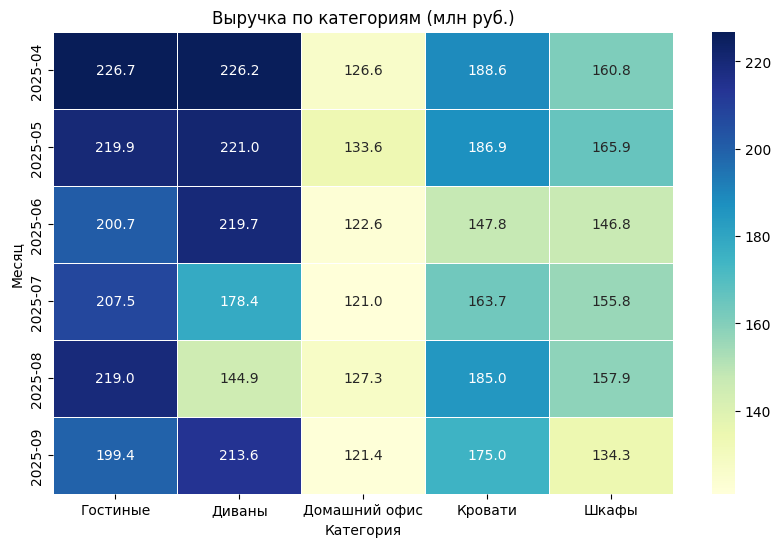

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

# Вытаскиваем из сводной таблицы только выручку (amount)
amount_pivot = pivot_df['amount']

plt.figure(figsize=(10, 6))
# Строим хитмэп: annot=True выводит цифры, fmt=".1f" оставляет один знак после запятой
sns.heatmap(amount_pivot, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5)

plt.title('Выручка по категориям (млн руб.)')
plt.ylabel('Месяц')
plt.xlabel('Категория')
plt.show()

Июль: Падение выручки с ~220 млн до ~178 млн — это изолированная проблема категории «Диваны», не связанная с общим сезоном. При этом маржинальность в июле сохранялась в норме (39%).

Падение объема продаж в июле могло быть вызвано нехваткой топовых товаров на складе (Out of Stock), отключением рекламных кампаний конкретно для этой категории или агрессивным демпингом со стороны конкурентов.

Август: Видя падение выручки в июле, менеджмент попытался стимулировать спрос в августе с помощью промо-акции. Фактическая скидка составила 30%. Выручку это не спасло (она упала еще сильнее до 145.1 млн), а маржинальность рухнула до 25%.

#### В качестве управленческих решений предлагаю провести аудит товарных остатков и маркетинговых активностей по категории "Диваны" за июль 2025 года для выявления причин резкого оттока покупателей.